# ***`Final Results`***
---
---
***Models:***
- Mistral
- LLama
- GPT-4o

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [19]:
df = pd.read_csv('../data/wmt-human_en_de_judged.csv').drop(
    columns=[
        'Unnamed: 0', 'id', 'source', 'reference', 'translation',
        'mean_human_score', 'individual_human_scores', 'n_annotations',
        'GPT-MINI_as_a_judge', 'MIXTRAL_as_a_judge',
    ]
)

print(df.shape)
df.head()

(9779, 6)


,human_#1,human_#2,human_#3,GPT_as_a_judge,MISTRAL_as_a_judge,LLAMA_as_a_judge
0,4,2,4,6,6,4
1,4,5,4,6,6,4
2,5,5,4,6,6,4
3,4,4,4,6,6,4
4,4,0,4,6,6,4


In [20]:
# human unique values
print(f"human #1 unique values: {df['human_#1'].unique()}")
print(f"human #2 unique values: {df['human_#2'].unique()}")
print(f"human #3 unique values: {df['human_#3'].unique()}")
print()
print("Mistral unique values: ", df['MISTRAL_as_a_judge'].unique())
print("LLAMA unique values: ", df['LLAMA_as_a_judge'].unique())
print("GPT-4o unique values: ", df['GPT_as_a_judge'].unique())

human #1 unique values: [4 5 3 6 2 1 0]
human #2 unique values: [2 5 4 0 6 3 1]
human #3 unique values: [4 1 2 5 3 6 0]

Mistral unique values:  ['6' '4' '5' '2' '6 (Perfect Meaning and Grammar)'
 '6 (The translation is perfect, as it is identical to the reference human translation.)'
 '0' 'Evaluation Error'
 '6 (The candidate translation is identical to the reference translation, so it receives a perfect score.)'
 '6 (The candidate translation is identical to the reference translation, so it is a perfect match.)']
LLAMA unique values:  ['4' '5' '3' 'Rating: 4' 'Rating: 5' '6' 'Evaluation Error' 'Rating: 3'
 '2']
GPT-4o unique values:  ['6' '5' '4' '3' '2' '0' 'Evaluation Error']


In [21]:
import re

def extract_valid_rating(series: pd.Series) -> pd.Series:
    """
    Extract leading number from strings in a Series,
    keeping only values between 0 and 6 inclusive.
    Non-matching or out-of-range values are returned as NaN.

    Parameters
    ----------
    series : pd.Series

    Returns
    -------
    pd.Series
        Series of integers in [0, 6] or NaN.
    """
    pattern = re.compile(r'^\s*(\d+)')

    values = []
    for item in series:
        text = str(item)
        match = pattern.match(text)
        if match:
            value = int(match.group(1))
            if 0 <= value <= 6:
                values.append(value)
            else:
                values.append(np.nan)
        else:
            values.append(np.nan)

    return pd.Series(values, index=series.index)

for col in df.columns:
    df[col] = extract_valid_rating(df[col])

print("Mistral unique values: ", df['MISTRAL_as_a_judge'].unique())
print("LLAMA unique values: ", df['LLAMA_as_a_judge'].unique())
print("GPT-4o unique values: ", df['GPT_as_a_judge'].unique())

Mistral unique values:  [ 6.  4.  5.  2.  0. nan]
LLAMA unique values:  [ 4.  5.  3. nan  6.  2.]
GPT-4o unique values:  [ 6.  5.  4.  3.  2.  0. nan]


In [22]:
# filter where nan
#df.dropna(inplace=True)

# cast all to int
df = df.astype(int, errors='ignore')

print(df.shape)

print()
print("Mistral unique values: ", df['MISTRAL_as_a_judge'].unique())
print("LLAMA unique values: ", df['LLAMA_as_a_judge'].unique())
print("GPT-4o unique values: ", df['GPT_as_a_judge'].unique())
print()

df.dtypes

(9779, 6)

Mistral unique values:  [ 6.  4.  5.  2.  0. nan]
LLAMA unique values:  [ 4.  5.  3. nan  6.  2.]
GPT-4o unique values:  [ 6.  5.  4.  3.  2.  0. nan]



human_#1                int64
human_#2                int64
human_#3                int64
GPT_as_a_judge        float64
MISTRAL_as_a_judge    float64
LLAMA_as_a_judge      float64
dtype: object

## ***`Diversity of Opinion`***
---

- initialize evaluator instance:

In [23]:
df.columns

Index(['human_#1', 'human_#2', 'human_#3', 'GPT_as_a_judge',
       'MISTRAL_as_a_judge', 'LLAMA_as_a_judge'],
      dtype='object')

📊 Computing disagreement distributions...


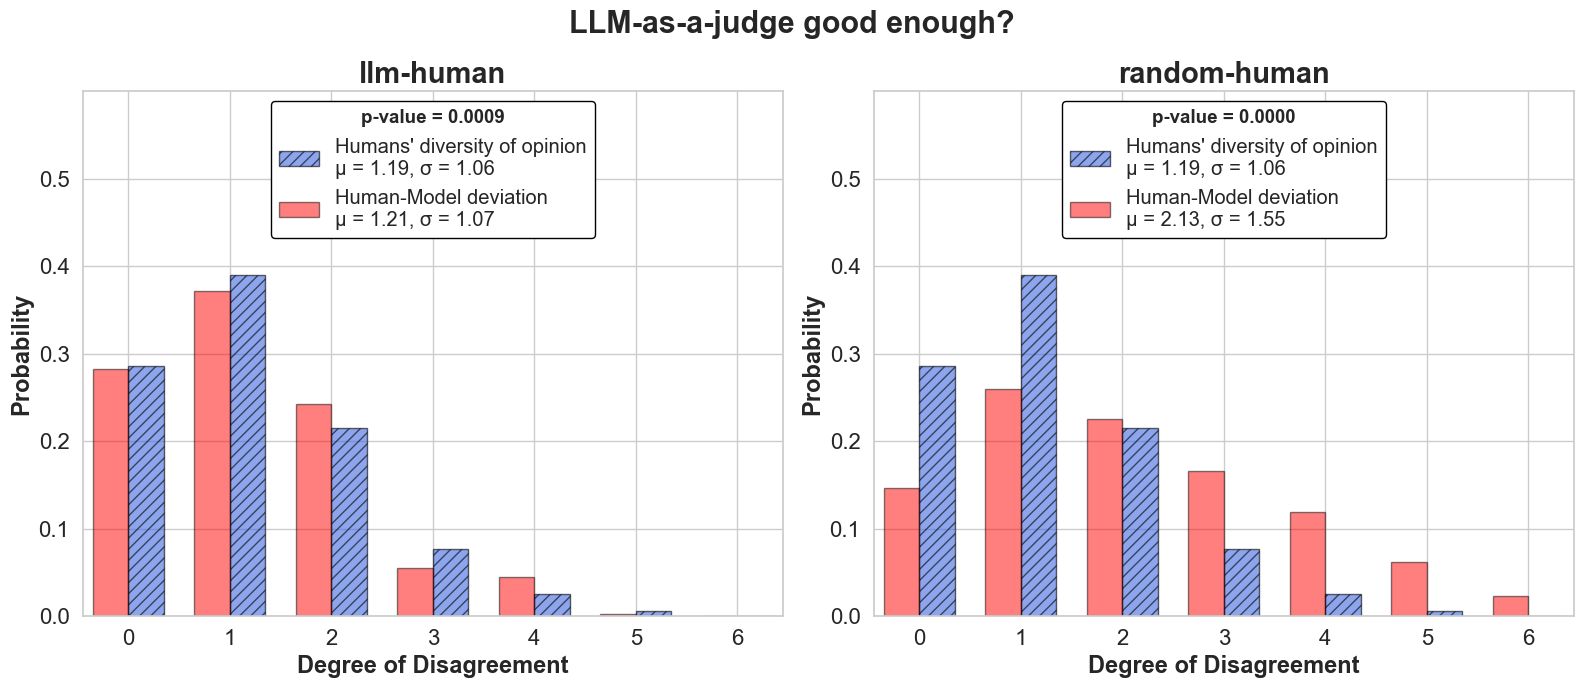

In [24]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..'))

from llm_good_enough import LLMGoodEnough

MIN, MAX = 0, 6

human_cols = [col for col in df.columns if col.startswith('human_')]
llm_cols = [col for col in df.columns if col.endswith('as_a_judge')]

LLM_Evaluator = LLMGoodEnough(
    df=df,
    human_cols=human_cols,
    llm_cols=llm_cols,
    min_score=MIN,
    max_score=MAX,
    verbosity=0
)

# visualize LLM-as-a-judge good enough
LLM_Evaluator.visualize_good_enough(llm_col='LLAMA_as_a_judge', y_lim=0.6)

### ***1. Human-Human Disagreement***

In [25]:
human_human_disagreements = LLM_Evaluator.compute_human_disagreements()

print(human_human_disagreements.shape)
# mean and std (=2 decimal places)
print(f"Mean: {round(human_human_disagreements.mean(), 2)}")
print(f"Std: {round(human_human_disagreements.std(), 2)}")

(29337,)
Mean: 1.19
Std: 1.06


### ***2. Human-LLM Disagreement***

In [26]:
# print shapes, mean and std (=2 decimal places)
print(f"LLAMA:")
llama_human_disagreements = LLM_Evaluator.compute_llm_human_disagreements('LLAMA_as_a_judge')
print(f"   - Shape: {llama_human_disagreements.shape}")
print(f"   - Mean: {round(llama_human_disagreements.mean(), 3)}")
print(f"   - Std: {round(llama_human_disagreements.std(), 3)}")
print()

print(f"MISTRAL:")
mistral_human_disagreements =  LLM_Evaluator.compute_llm_human_disagreements('MISTRAL_as_a_judge')
print(f"   - Shape: {mistral_human_disagreements.shape}")
print(f"   - Mean: {round(mistral_human_disagreements.mean(), 3)}")
print(f"   - Std: {round(mistral_human_disagreements.std(), 3)}")
print()

print(f"GPT-4o:")
gpt4o_human_disagreements = LLM_Evaluator.compute_llm_human_disagreements('GPT_as_a_judge')
print(f"   - Shape: {gpt4o_human_disagreements.shape}")
print(f"   - Mean: {round(gpt4o_human_disagreements.mean(), 3)}")
print(f"   - Std: {round(gpt4o_human_disagreements.std(), 3)}")

LLAMA:
   - Shape: (27906,)
   - Mean: 1.214
   - Std: 1.067

MISTRAL:
   - Shape: (28383,)
   - Mean: 1.808
   - Std: 1.414

GPT-4o:
   - Shape: (26427,)
   - Mean: 1.564
   - Std: 1.24


### 3. ***Human-Random Judge Disagreement***


***NOTE:*** Is internally computed during instance initialization!

In [27]:
import random

# set seed for reproducibility
random.seed(42)

MIN, MAX = 0, 6

# compute random judge
df['RANDOM_as_a_judge'] = np.random.randint(MIN, MAX + 1, size=len(df))

# compute human-random judge disagreement
human_random_disagreements = LLM_Evaluator.compute_llm_human_disagreements('RANDOM_as_a_judge')

# print shapes, mean and std (=2 decimal places)
print(f"RANDOM:")
print(f"   - Shape: {human_random_disagreements.shape}")
print(f"   - Mean: {round(human_random_disagreements.mean(), 3)}")
print(f"   - Std: {round(human_random_disagreements.std(), 3)}")

RANDOM:
   - Shape: (29337,)
   - Mean: 2.129
   - Std: 1.547


### ***`Results`***
---

- *`Null hypothesis (H₀):`* The LLM–human disagreement distribution is not worse than the human–human disagreement distribution.
- *`Alternative hypothesis (H₁):`* The LLM–human disagreement is greater (i.e., worse aligned) than human–human disagreement.

***From the paper:***

- “... test the hypothesis that the probability to find a bigger value in HJ (LLM-Human) than in HD (Human-Human) is as high as finding a smaller one.”
- “We use mannwhitneyu(x=HJ, y=HD, alternative='greater')”

In [28]:
from scipy.stats import mannwhitneyu

# compute mann-whitney u test and round to 4 decimal places
llama_human_pvalue = mannwhitneyu(
    llama_human_disagreements, human_human_disagreements, alternative='greater'
).pvalue
print(f"LLAMA vs. Human: {round(llama_human_pvalue, 4)}")

gpt4o_human_pvalue = mannwhitneyu(
    gpt4o_human_disagreements, human_human_disagreements, alternative='greater'
).pvalue

print(f"GPT-4o vs. Human: {round(gpt4o_human_pvalue, 4)}")

mistral_human_pvalue = mannwhitneyu(
    mistral_human_disagreements, human_human_disagreements, alternative='greater'
).pvalue

print(f"MISTRAL vs. Human: {round(mistral_human_pvalue, 4)}")

random_human_pvalue = mannwhitneyu(
    human_random_disagreements, human_human_disagreements, alternative='greater'
).pvalue

print(f"RANDOM vs. Human: {round(random_human_pvalue, 4)}")

LLAMA vs. Human: 0.0009
GPT-4o vs. Human: 0.0
MISTRAL vs. Human: 0.0
RANDOM vs. Human: 0.0


✅ Figure saved as SVG → ../svg/wmt_barplot.svg


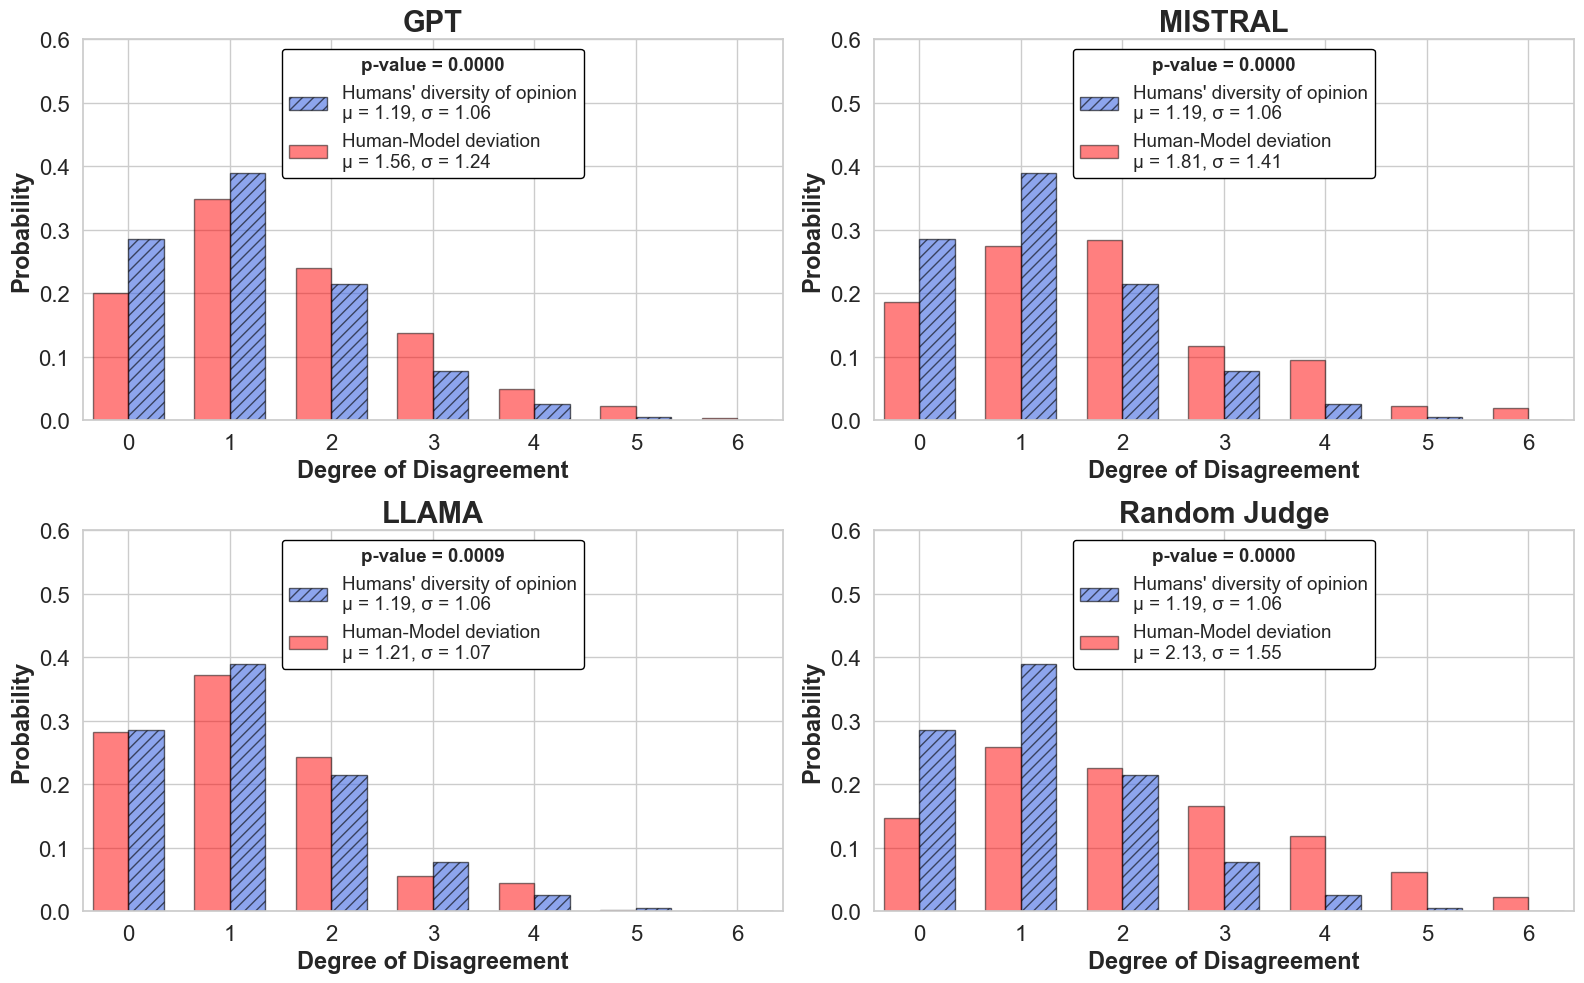

In [29]:
LLM_Evaluator.plot_judges_grid(
    bins=np.arange(0, 8),
    bar_width=0.35,
    y_lim=0.6,
    save_path="../svg/wmt_barplot.svg"
)

#### Robutsness

→ Running robustness analysis for all models ...


/Users/sebastianwefers/Desktop/projects/LLM_as_a_Judge_good_enough/wmt-human/src/../../llm_good_enough/evaluator.py:818: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pA, fill=True, ax=axes[0], label=label_pA, alpha=0.5, color="royalblue")
/Users/sebastianwefers/Desktop/projects/LLM_as_a_Judge_good_enough/wmt-human/src/../../llm_good_enough/evaluator.py:819: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pB, fill=True, ax=axes[0], label=label_pB, alpha=0.5, color="#333333")
/Users/sebastianwefers/Desktop/projects/LLM_as_a_Judge_good_enough/wmt-human/src/../../llm_good_enough/evaluator.py:829: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(edgecolor="black", facecolor="white", framealp

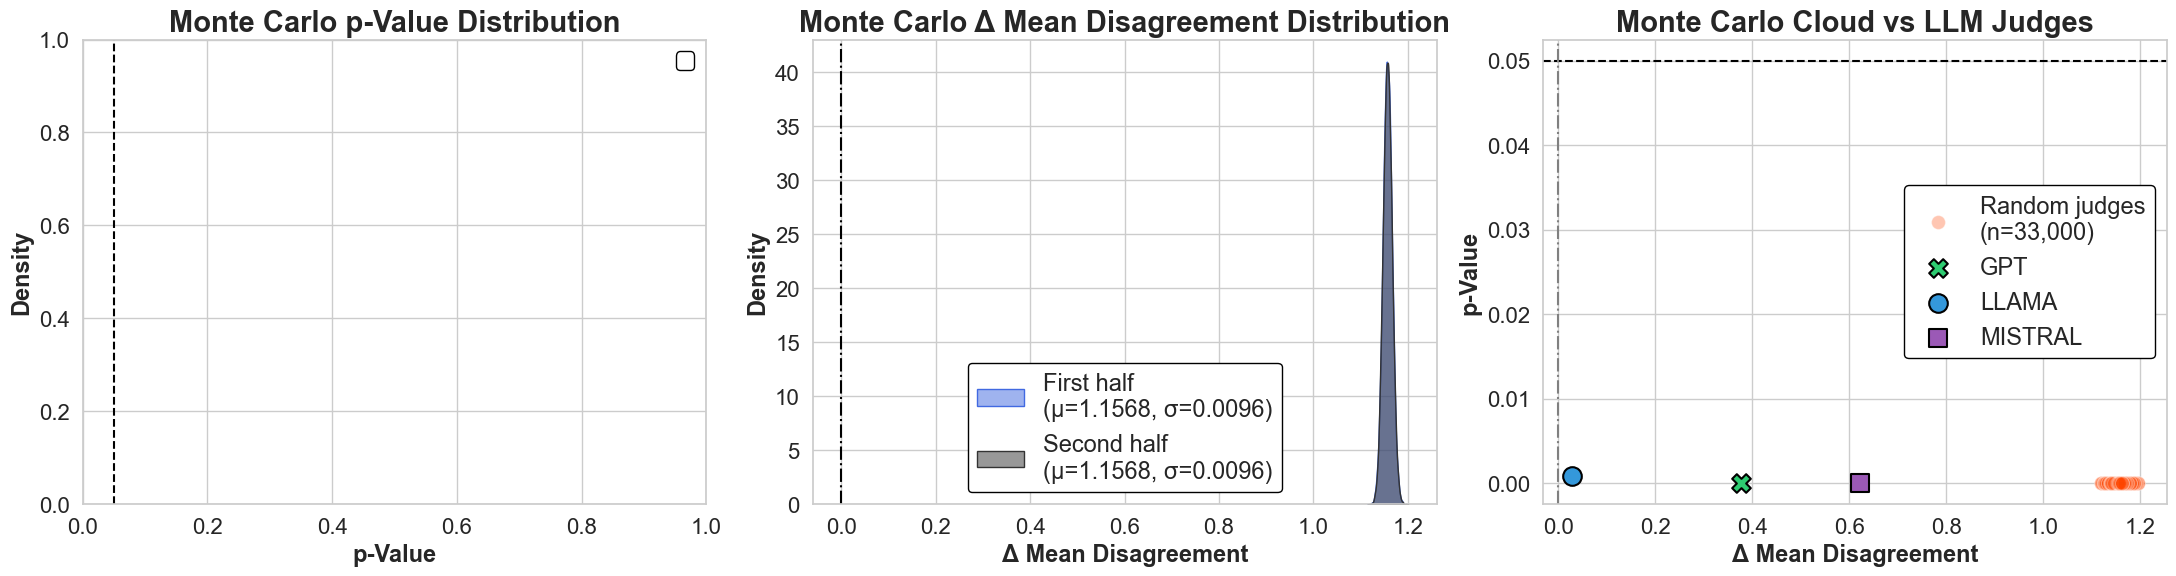

In [30]:
# --- Robustness visualization for all models in one figure ---

models = ['GPT', 'LLAMA', 'MISTRAL']
llm_cols = [f"{model}_as_a_judge" for model in models]

print("→ Running robustness analysis for all models ...")
LLM_Evaluator.plot_monte_carlo_robustness_multi(
    llm_cols=llm_cols,
    iterations=33_000,
    save_path="../svg/wmt_monte_carlo_robustness.svg"
)

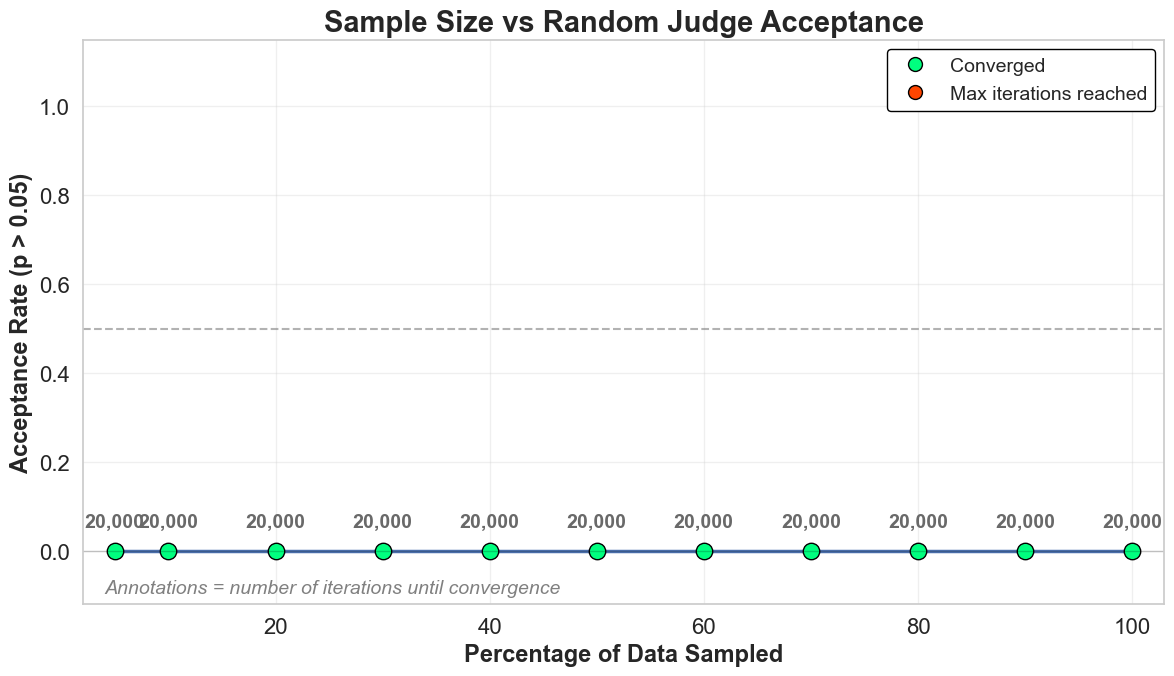

In [31]:
LLM_Evaluator.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    min_iterations=20_000,
    max_iterations=500_000,
    parallel=True,
    save_path="../svg/wmt_human_stability.svg"
)

In [ ]:
LLM_Evaluator.plot_human_stability_analysis(
    percentages=[10, 20, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500],
    convergence_threshold=0.00001,
    min_iterations=1_000,
    max_iterations=100_000,
    save_path="../svg/wmt_human_stability_100plus.svg"
)